# Learning to Implement Variational Autoencoders

## TO-DO:
- implement VQ-VAE

In [1]:
from collections.abc import Callable
from copy import deepcopy
from IPython.display import HTML
import matplotlib
import matplotlib.animation as animation
import math
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.distributions as td
from torch.distributions.mixture_same_family import MixtureSameFamily
from torch.distributions.kl import register_kl
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.parametrize as parametrize
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
from torchvision.transforms.functional import to_pil_image
from tqdm import tqdm
from typing import List, Tuple, Dict, Iterable

import sys
sys.path.append("/home/alzub/projects/ggdl_self_learn/code/")
from plot_utils import set_plot_style
from nn_.mlp import MLP
from generative.conditioning import UNetTimeClassDependent
from generative.base_dists import GaussianBase
from utilities.prebuilt_nns import create_mnist_classifier
from utilities.metrics import FIDEvaluator

In [2]:
set_plot_style()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PROJECT_DIR = Path("/home/alzub/projects/ggdl_self_learn")
DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = DATA_DIR / "models/vae"
SAMPLE_DIR = DATA_DIR / "samples/vae"

plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128
plt.ioff()

# 0. Prerequisites

## 0.1 Data

### 0.1.1 Toy Distributions

In [3]:
class TwoGaussians:
    def __init__(self):
        """
        A simple class to define an uneven mixture of two Gaussians.
        """

        mixture = td.Categorical(torch.tensor([1/5, 4/5]))
        components = td.Independent(td.Normal(
            torch.Tensor([
                [0.75, 0.75],
                [0.25, 0.25]
            ]),
            torch.Tensor([
                [0.1, 0.1],
                [0.1, 0.1]
            ])
        ), 1)
        self.distribution = MixtureSameFamily(mixture, components)

        self.xlim = (0, 1)
        self.ylim = (0, 1)

    def __call__(self):
        """
        Return the distribution.
        Returns:
        distribution: [torch.distributions.Distribution]
        """
        return self.distribution


class ExtendedUniform(td.Uniform):
    def __init__(self, low, high, validate_args=None, outside_value=-float('inf')):
        """
        A uniform distribution that returns a constant value for values outside the support
        """
        super(ExtendedUniform, self).__init__(low, high, validate_args)
        self.outside_value = outside_value

    def log_prob(self, value):
        # Check if the value is within the support
        in_support = (value >= self.low) & (value <= self.high)
        safe_value = torch.where(in_support, value, self.low)
        log_prob = super().log_prob(safe_value)
        
        # Set log_prob to self.outside_value for values outside the support
        log_prob = torch.where(in_support, log_prob, torch.full_like(log_prob, self.outside_value))
        return log_prob
    
    @td.constraints.dependent_property(is_discrete=False, event_dim=0)
    def support(self):
        return td.constraints.real

class Chequerboard:
    def __init__(self, grid_size=3, bounds=[0.0, 1.0]):
        """
        A simple class to define the Chequerboard distribution.
        """

        square_size = (bounds[1] - bounds[0]) / grid_size

        weights = []
        low_list = []
        high_list = []
        for i in range(grid_size):
            for j in range(grid_size):
                if (i + j) % 2 == 0:
                    low_x = bounds[0] + i * square_size
                    high_x = low_x + square_size
                    low_y = bounds[0] + j * square_size
                    high_y = low_y + square_size
                    
                    low_list.append([low_x, low_y])
                    high_list.append([high_x, high_y])
                    weights.append(1.0)

        mixture = td.Categorical(torch.tensor(weights))
        #components = td.Independent(td.uniform.Uniform(torch.tensor(low_list), torch.tensor(high_list)), 1)
        components = td.Independent(ExtendedUniform(torch.tensor(low_list), torch.tensor(high_list)), 1)
        self.distribution = MixtureSameFamily(mixture, components)

        self.xlim = bounds
        self.ylim = bounds

    def __call__(self):
        """
        Return the distribution.
        Returns:
        distribution: [torch.distributions.Distribution]
        """
        return self.distribution

### 0.1.2 MNIST

In [4]:
batch_size = 256

mnist_train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        PROJECT_DIR / "data", train=True, download=True,
        transform=transforms.Compose([transforms.ToTensor()])
    ),
    batch_size=batch_size, shuffle=True
)
mnist_test_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        PROJECT_DIR / "data", train=False, download=True,
        transform=transforms.Compose([transforms.ToTensor()])
    ),
    batch_size=batch_size*4, shuffle=True
)

# X. VAE Implementations

## 1. Base Distributions

In [5]:
class MixtureOfGaussiansBase(nn.Module):
    def __init__(
        self, dimensionality: Tuple[int], num_components: int,
        logit_init: float=3.0, logvar_init: float=-4.6
    ) -> None:
        super().__init__()

        self.dim = dimensionality
        self.k = num_components
        self.mix_logits = nn.Parameter(
            torch.ones(self.k) * logit_init, requires_grad=True)
        self.means = nn.Parameter(
            torch.randn(self.k, *self.dim), requires_grad=True)
        self.logvars = nn.Parameter(torch.ones(self.k, *self.dim) * logvar_init)

    def forward(self) -> td.Distribution:
        mix_dist = td.Categorical(logits=self.mix_logits)
        comp_dist = td.Independent(
            td.Normal(loc=self.means, scale=torch.exp(0.5 * self.logvars)),
            reinterpreted_batch_ndims=1
        )
        return td.MixtureSameFamily(mix_dist, comp_dist)

class VampBase(nn.Module):
    def __init__(
            self, dimensonality: Tuple[int], num_components: int,
            encoder: nn.Module|nn.Sequential, logit_init: float=3.0,
            pseudo_init: float=1.0, unflatten_flag=False
        ) -> None:
        super().__init__()

        self.dim = dimensonality
        self.k = num_components
        self.pseudo_inputs = nn.Parameter(
            torch.rand(self.k, *self.dim) * pseudo_init,
            requires_grad=True
        )
        self.mix_logits = nn.Parameter(
            torch.ones(self.k) * logit_init, requires_grad=True)
        self.enc = encoder
        self.unflatten = unflatten_flag
    
    def forward(self) -> td.Distribution:
        mix_dist = td.Categorical(logits=self.mix_logits)
        comp_dist = self.enc(self.pseudo_inputs)
        
        return td.MixtureSameFamily(mix_dist, comp_dist)

## 2. Encoders

In [6]:
class Encoder(nn.Module):
    def __init__(self, encoder_net: nn.Module|nn.Sequential) -> None:
        super().__init__()

        self.net = encoder_net
    
    def forward(
        self, x: torch.Tensor, y: torch.Tensor|None=None) -> td.Distribution:
        x = self.net(x, y=y)
        return self.reparameterize(x)
    
    def reparameterize(self, x: torch.Tensor) -> td.Distribution:
        raise NotImplementedError

class GaussianEncoder(Encoder):    
    def reparameterize(self, x: torch.Tensor) -> td.Distribution:
        mean, logvar = torch.chunk(x, 2, dim=-1)
        return td.Independent(
            td.Normal(loc=mean, scale=torch.exp(0.5 * logvar)), 1)

## 3. Decoders

In [7]:
class Decoder(nn.Module):
    def __init__(
        self, decoder_net: nn.Module|nn.Sequential, dimensionality: Tuple
    ) -> None:
        super().__init__()

        self.net = decoder_net
        self.dim = dimensionality
        if isinstance(self.dim, (tuple, list, torch.Size)):
            self.event_ndims = len(self.dim)
        else:
            self.event_ndims = 1
    
    def forward(
        self, x: torch.Tensor, y: torch.Tensor|None=None) -> td.Distribution:
        x = self.net(x, y=y)
        return self.out_dist(x)
    
    def out_dist(self, x: torch.Tensor) -> td.Distribution:
        raise NotImplementedError

class BernoulliDecoder(Decoder):    
    def out_dist(self, x: torch.Tensor) -> td.Distribution:
        return td.Independent(td.Bernoulli(logits=x), self.event_ndims)

class GaussianDecoder(Decoder):
    def __init__(
        self, decoder_net: nn.Module|nn.Sequential, dimensionality: Tuple,
        variance_type: str="scalar", logvar_init: float=-4.6
    ) -> None:
        super().__init__(
            decoder_net=decoder_net, dimensionality=dimensionality)

        match variance_type:
            case "scalar":
                self.logvar = nn.Parameter(
                    torch.ones((1,)) * logvar_init, requires_grad=True)
            case "diagonal":
                self.logvar = nn.Parameter(
                    torch.ones((self.dim[-1],)) * logvar_init,
                    requires_grad=True
                )
            case "dense":
                self.logvar = nn.Parameter(
                    torch.ones(*self.dim) * logvar_init, requires_grad=True)

    def out_dist(self, x: torch.Tensor) -> td.Distribution:
        means = x
        return td.Independent(
            td.Normal(loc=means, scale=torch.exp(0.5 * self.logvar)),
            self.event_ndims
        )

## 4. Main Class

In [8]:
class VAE(nn.Module):
    def __init__(
            self, prior: nn.Module, encoder: nn.Module|nn.Sequential,
            decoder: nn.Module|nn.Sequential
        ) -> None:
        super().__init__()

        self.prior = prior
        self.enc = encoder
        self.dec = decoder
    
    def forward(
            self, x: torch.Tensor) -> tuple[td.Distribution, td.Distribution]:
        posterior = self.enc(x)
        latent = posterior.rsample()
        lik = self.dec(latent)
        return posterior, lik

    def sample(
        self, sample_shape: Tuple[int]|torch.Size=(1,),
        y: torch.Tensor|None=None, **kwargs
    ) -> torch.Tensor:
        latent = self._prior_prep().sample(sample_shape)
        return self.dec(latent, y=y).sample()
    
    def _prior_prep(self) -> td.Distribution:
        return self.prior()

## 5. Loss Function (ELBO)

In [94]:
class ELBO(nn.modules.loss._Loss):
    def __init__(self) -> None:
        super().__init__()
    
    def forward(
            self, prior: td.Distribution|nn.Module, posterior: td.Distribution,
            likelihood: td.Distribution, target: torch.Tensor, *args
        ) -> torch.Tensor:
        reconstruction = self.recon_loss(likelihood, target)
        regularization = self.regul_loss(posterior, prior)

        elbo = torch.mean(reconstruction - regularization, dim=0)
        return -elbo
    
    def recon_loss(
        self, likelihood: td.Distribution, target: torch.Tensor
    ) -> torch.Tensor:
        return likelihood.log_prob(target)
    
    def regul_loss(
        self, posterior: td.Distribution, prior: td.Distribution
    ) -> torch.Tensor:
        return td.kl_divergence(posterior, prior)

class ELBOAnnealedBeta(ELBO):
    def __init__(
        self, total_steps: int, beta_start: float, beta_end: float=1.0
    ) -> None:
        super().__init__()

        self.betas = torch.linspace(beta_start, beta_end, total_steps)
    
    def forward(
        self, prior: td.Distribution|nn.Module, posterior: td.Distribution,
        likelihood: td.Distribution, target: torch.Tensor, step: int
    ) -> torch.Tensor:
        reconstruction = self.recon_loss(likelihood, target)
        regularization = self.regul_loss(posterior, prior)

        beta = self.betas[step]
        elbo = torch.mean(reconstruction - beta * regularization, dim=0)
        return -elbo


@register_kl(td.Independent, td.MixtureSameFamily)
def _independentnormal_mixturesamefamily_approximate(p, q, n_samples=10000):
    samples = p.rsample((n_samples,))
    log_p = p.log_prob(samples)
    
    log_q = q.log_prob(samples)

    return (log_p - log_q).mean(dim=0)

# 1. VAEs on Toy Data

## 1.1 TwoGaussians

In [10]:
# Generate the data
n_data = 10000000
toy = TwoGaussians()
train_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)

### 1.1.1 Continuous-Latent VAEs on TwoGaussians

In [ ]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)
epochs = 3

latent_size = 2
enc = GaussianEncoder(MLP(
    x_sample_size, latent_size*2, [32, 128, 32],
    act_funs=[nn.GELU]*3 + [None]
))
dec = GaussianDecoder(
    MLP(
        latent_size, x_sample_size, [32, 128, 32],
        act_funs=[nn.GELU]*3 + [None]
    ), (x_sample_size,), variance_type="diagonal"
)
for i, prior_type in enumerate(["std", "mog", "vamp"]):
    match prior_type:
        case "std":
            prior = GaussianBase((latent_size,))
        case "mog":
            prior = MixtureOfGaussiansBase((latent_size,), 2)
        case "vamp":
            prior = VampBase((x_sample_size,), 4, enc)
    model = VAE(prior, enc, dec).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()

    total_steps = len(train_loader)*epochs
    loss_fun = ELBOAnnealedBeta(total_steps, 0.0).to(DEVICE)
    progress_bar = tqdm(range(total_steps), desc="Training")
    s = 0
    for epoch in range(epochs):
        for x in train_loader:
            optimizer.zero_grad()

            x = x.to(DEVICE)

            post, lik = model(x)
            loss = loss_fun(model.prior(), post, lik, x, s)

            loss.backward()
            optimizer.step()

            # Update progress bar
            progress_bar.set_postfix(
                loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
            progress_bar.update()

            s += 1

    torch.save(
        model.state_dict(),
        MODEL_DIR / f"toy1_vae_{prior_type}_{epochs}_n_epochs.pt"
    )

Training: 100%|█████████▉| 2999/3000 [03:15<00:00, 16.90it/s, epoch=3/3, loss=⠀     -1.1290]

In [77]:
progress_bar.reset()

/home/alzub/tmp/ipykernel_281901/596595208.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


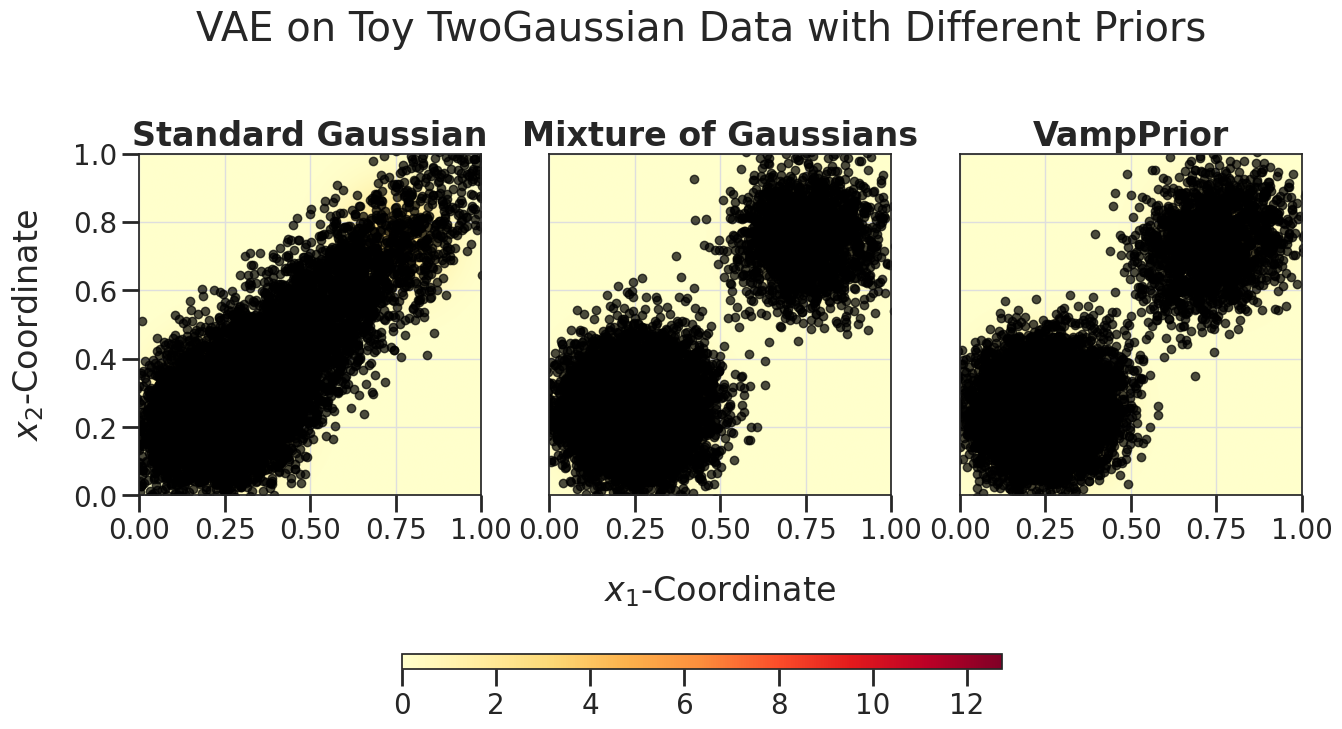

In [ ]:
prior_name_map = {
    "std": "Standard Gaussian", "mog": "Mixture of Gaussians",
    "vamp": "VampPrior"
}

coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig = plt.figure(figsize=(15, 15))
gs_plot = fig.add_gridspec(1, 3, bottom=0.1)
gs_cbar = fig.add_gridspec(1, 1, top=0.27, bottom=0.26, left=0.3, right=0.7)

epochs = 3
latent_size = 2
enc = GaussianEncoder(MLP(
    x_sample_size, latent_size*2, [32],
    act_funs=[nn.GELU]*1 + [None]
))
dec = GaussianDecoder(
    MLP(
        latent_size, x_sample_size, [32],
        act_funs=[nn.GELU]*1 + [None]
    ), (x_sample_size,), variance_type="diagonal"
)
for i, prior_type in enumerate(["std", "mog", "vamp"]):
    match prior_type:
        case "std":
            prior = GaussianBase((latent_size,))
        case "mog":
            prior = MixtureOfGaussiansBase((latent_size,), 2)
        case "vamp":
            prior = VampBase((x_sample_size,), 2, enc)
    model = VAE(prior, enc, dec).to(DEVICE)
    model.load_state_dict(torch.load(
        MODEL_DIR / f"toy1_vae_{prior_type}_{epochs}_n_epochs.pt",
        map_location=torch.device(DEVICE)
    ))
    with torch.no_grad():
        model.eval()
        samples = model.sample((10000,))
        samples = samples.detach().cpu().numpy()

    ax = fig.add_subplot(gs_plot[i])
    im = ax.imshow(
        prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
        origin='lower', cmap='YlOrRd'
    )

    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.7, color="black")

    ax.set_xlim(toy.xlim)
    ax.set_ylim(toy.ylim)
    ax.set_aspect("equal")
        
    if i > 0:
        ax.tick_params(left=False, labelleft=False)
        ax.set_ylabel("")
    else:
        ax.set_ylabel("$x_2$-Coordinate", labelpad=20)
    
    if i != 1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("$x_1$-Coordinate", labelpad=20)
    
    ax.set_title(prior_name_map[prior_type], weight="bold")
    
ax_cbar = fig.add_subplot(gs_cbar[0])
fig.colorbar(im, location="bottom", cax=ax_cbar)

fig.suptitle("VAE on Toy TwoGaussian Data with Different Priors", y=0.7)

plt.show()

## 1.2 Chequerboard

In [80]:
# Generate the data
n_data = 10000000
toy = Chequerboard(bounds=[-2, 2])
train_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)

### 1.2.1 Continuous-Latent VAEs on TwoGaussians

In [93]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)
epochs = 3

latent_size = 2
enc = GaussianEncoder(MLP(
    x_sample_size, latent_size*2, [256, 128, 64, 32],
    act_funs=[nn.GELU]*4 + [None]
))
dec = GaussianDecoder(
    MLP(
        latent_size, x_sample_size, [32, 64, 128, 256],
        act_funs=[nn.GELU]*4 + [None]
    ), (x_sample_size,), variance_type="diagonal"
)
for i, prior_type in enumerate(["std", "mog", "vamp"]):
    match prior_type:
        case "std":
            prior = GaussianBase((latent_size,))
        case "mog":
            prior = MixtureOfGaussiansBase((latent_size,), 5)
        case "vamp":
            prior = VampBase((x_sample_size,), 10, enc)
    model = VAE(prior, enc, dec).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    model.train()

    total_steps = len(train_loader)*epochs
    loss_fun = ELBOAnnealedBeta(total_steps, 0.0).to(DEVICE)
    progress_bar = tqdm(range(total_steps), desc="Training")
    s = 0
    for epoch in range(epochs):
        for x in train_loader:
            optimizer.zero_grad()

            x = x.to(DEVICE)

            post, lik = model(x)
            loss = loss_fun(model.prior(), post, lik, x, s)

            loss.backward()
            optimizer.step()

            # Update progress bar
            progress_bar.set_postfix(
                loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
            progress_bar.update()

            s += 1

    torch.save(
        model.state_dict(),
        MODEL_DIR / f"toy2_vae_{prior_type}_{epochs}_n_epochs.pt"
    )

Training: 100%|██████████| 3000/3000 [04:47<00:00, 10.42it/s, epoch=3/3, loss=⠀      3.1927]


In [92]:
progress_bar.reset()

Training:   0%|          | 0/3000 [00:00<?, ?it/s, epoch=3/3, loss=⠀      2.7943]           

/home/alzub/tmp/ipykernel_281901/2920830278.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


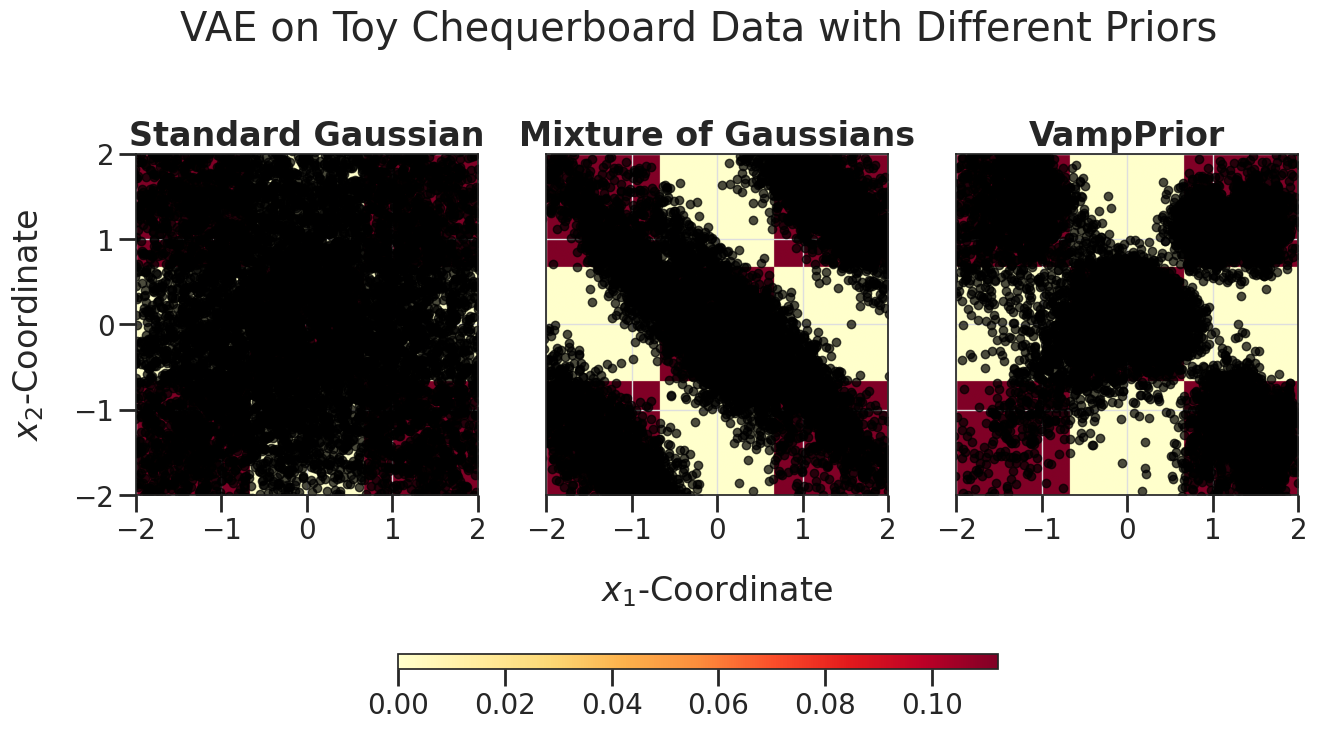

In [95]:
prior_name_map = {
    "std": "Standard Gaussian", "mog": "Mixture of Gaussians",
    "vamp": "VampPrior"
}

coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig = plt.figure(figsize=(15, 15))
gs_plot = fig.add_gridspec(1, 3, bottom=0.1)
gs_cbar = fig.add_gridspec(1, 1, top=0.27, bottom=0.26, left=0.3, right=0.7)

epochs = 3
latent_size = 2
enc = GaussianEncoder(MLP(
    x_sample_size, latent_size*2, [256, 128, 64, 32],
    act_funs=[nn.GELU]*4 + [None]
))
dec = GaussianDecoder(
    MLP(
        latent_size, x_sample_size, [32, 64, 128, 256],
        act_funs=[nn.GELU]*4 + [None]
    ), (x_sample_size,), variance_type="diagonal"
)
for i, prior_type in enumerate(["std", "mog", "vamp"]):
    match prior_type:
        case "std":
            prior = GaussianBase((latent_size,))
        case "mog":
            prior = MixtureOfGaussiansBase((latent_size,), 5)
        case "vamp":
            prior = VampBase((x_sample_size,), 10, enc)
    model = VAE(prior, enc, dec).to(DEVICE)
    model.load_state_dict(torch.load(
        MODEL_DIR / f"toy2_vae_{prior_type}_{epochs}_n_epochs.pt",
        map_location=torch.device(DEVICE)
    ))
    with torch.no_grad():
        model.eval()
        samples = model.sample((10000,))
        samples = samples.detach().cpu().numpy()

    ax = fig.add_subplot(gs_plot[i])
    im = ax.imshow(
        prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
        origin='lower', cmap='YlOrRd'
    )

    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.7, color="black")

    ax.set_xlim(toy.xlim)
    ax.set_ylim(toy.ylim)
    ax.set_aspect("equal")
        
    if i > 0:
        ax.tick_params(left=False, labelleft=False)
        ax.set_ylabel("")
    else:
        ax.set_ylabel("$x_2$-Coordinate", labelpad=20)
    
    if i != 1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("$x_1$-Coordinate", labelpad=20)
    
    ax.set_title(prior_name_map[prior_type], weight="bold")
    
ax_cbar = fig.add_subplot(gs_cbar[0])
fig.colorbar(im, location="bottom", cax=ax_cbar)

fig.suptitle("VAE on Toy Chequerboard Data with Different Priors", y=0.7)

plt.show()